In [10]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.func import jacrev


# ============================================================
# Device selection
# Priority: CUDA -> MPS -> CPU
# ============================================================

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


# ============================================================
# Circle dataset
# ============================================================

def sample_circle(n, device=device):
    theta = 2 * np.pi * torch.rand(n, device=device)

    z = torch.stack(
        [
            torch.cos(theta),
            torch.sin(theta),
        ],
        dim=-1,
    )

    return z


def sample_xt(n, device=device):
    z = sample_circle(n, device)

    eps = torch.randn_like(z)

    t = torch.rand(n, 1, device=device)

    x = t * z + (1 - t) * eps

    target_velocity = z - eps

    return x, t, target_velocity


# ============================================================
# Flow matching network
# ============================================================

class FMNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(3, 32),
            nn.SiLU(),
            nn.Linear(32, 32),
            nn.SiLU(),
            nn.Linear(32, 2),
        )

    def forward(self, x, t):
        inp = torch.cat([x, t], dim=-1)
        return self.net(inp)

class RadialFM(nn.Module):

    def __init__(self):
        super().__init__()

        self.mlp = nn.Sequential(
            nn.Linear(2,32),
            nn.Tanh(),
            nn.Linear(32,32),
            nn.Tanh(),
            nn.Linear(32,1)
        )

    def forward(self,x,t):

        r = torch.linalg.norm(
            x,
            dim=-1,
            keepdim=True
        )

        inp = torch.cat([r,t],dim=-1)

        u = self.mlp(inp)

        return u * x/(r+1e-8)

net = FMNet().to(device)


# ============================================================
# Training
# ============================================================

def train(
    net,
    steps=50000,
    batch_size=4096,
    lr=1e-4,
):

    opt = torch.optim.Adam(
        net.parameters(),
        lr=lr,
    )

    for step in range(steps):

        x, t, v = sample_xt(
            batch_size,
            device=device,
        )

        pred = net(x, t)

        loss = ((pred - v) ** 2).mean()

        opt.zero_grad()
        loss.backward()
        opt.step()

        if step % 1000 == 0:
            print(
                f"step={step:6d} "
                f"loss={loss.item():.6f}"
            )


# Uncomment to train
train(net)

Using device: mps
step=     0 loss=1.406501
step=  1000 loss=1.040106
step=  2000 loss=1.030601
step=  3000 loss=0.993259
step=  4000 loss=0.969070
step=  5000 loss=0.973870
step=  6000 loss=0.987174
step=  7000 loss=0.943316
step=  8000 loss=0.944852
step=  9000 loss=0.931683
step= 10000 loss=0.969035
step= 11000 loss=0.933957
step= 12000 loss=0.925348
step= 13000 loss=0.920150
step= 14000 loss=0.963955
step= 15000 loss=0.942454
step= 16000 loss=0.927885
step= 17000 loss=0.911874
step= 18000 loss=0.950734
step= 19000 loss=0.956481
step= 20000 loss=0.947204
step= 21000 loss=0.916250
step= 22000 loss=0.915418
step= 23000 loss=0.940714
step= 24000 loss=0.915649
step= 25000 loss=0.944244
step= 26000 loss=0.915962
step= 27000 loss=0.946377
step= 28000 loss=0.912968
step= 29000 loss=0.930131
step= 30000 loss=0.917636
step= 31000 loss=0.935128
step= 32000 loss=0.928279
step= 33000 loss=0.931181
step= 34000 loss=0.928924
step= 35000 loss=0.932964
step= 36000 loss=0.916744
step= 37000 loss=0.9

Evaluating t=0.7
Evaluating t=0.8
Evaluating t=0.9
Evaluating t=0.95
Evaluating t=0.98
Evaluating t=0.99


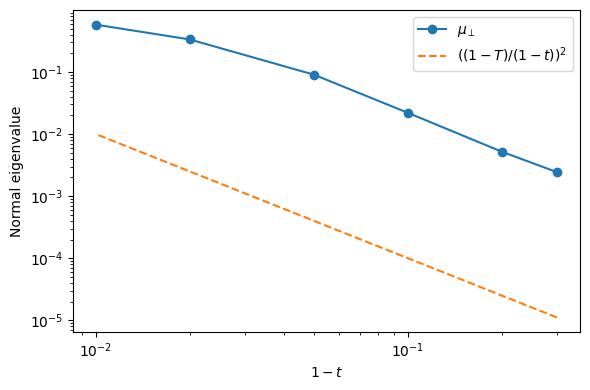

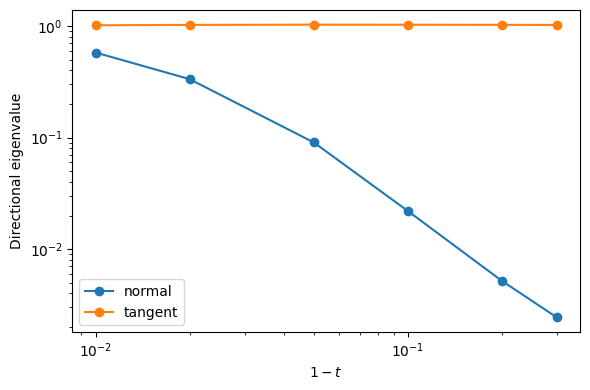

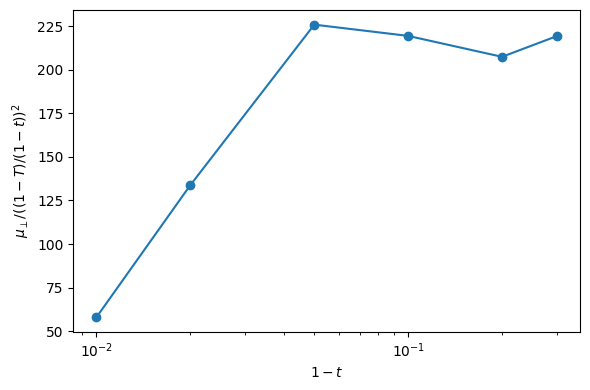


Results:
t=0.700  mu_perp=2.4372e-03  mu_tan=1.0232e+00
t=0.800  mu_perp=5.1860e-03  mu_tan=1.0253e+00
t=0.900  mu_perp=2.1944e-02  mu_tan=1.0273e+00
t=0.950  mu_perp=9.0359e-02  mu_tan=1.0290e+00
t=0.980  mu_perp=3.3423e-01  mu_tan=1.0236e+00
t=0.990  mu_perp=5.7880e-01  mu_tan=1.0152e+00


In [11]:
# ============================================================
# Drift
# ============================================================

def drift(t, x):

    tt = torch.full(
        (x.shape[0], 1),
        t,
        device=x.device,
    )

    return net(x, tt)


# ============================================================
# Jacobian of drift
# ============================================================

def drift_jacobian(t, x):

    def single(xx):

        tt = torch.tensor(
            [[t]],
            device=xx.device,
            dtype=xx.dtype,
        )

        return net(xx[None], tt)[0]

    return jacrev(single)(x)


# ============================================================
# Variational equation
# ============================================================

@torch.no_grad()
def integrate_with_jacobian(
    x0,
    t0,
    T,
    nsteps=500,
):

    dt = (T - t0) / nsteps

    x = x0.clone()

    J = torch.eye(
        2,
        device=x.device,
        dtype=x.dtype,
    )

    s = t0

    for _ in range(nsteps):

        v = drift(
            s,
            x[None],
        )[0]

        A = drift_jacobian(
            s,
            x,
        )

        x = x + dt * v

        J = J + dt * (A @ J)

        s += dt

    return x, J


# ============================================================
# Circle tangent / normal directions
# ============================================================

def normal_tangent(x):

    n = x / torch.linalg.norm(x)

    tau = torch.stack(
        [
            -n[1],
            n[0],
        ]
    )

    return n, tau


# ============================================================
# Directional eigenvalues
# ============================================================

@torch.no_grad()
def estimate_mu(
    x,
    t,
    T,
):

    _, J = integrate_with_jacobian(
        x,
        t,
        T,
    )

    n, tau = normal_tangent(x)

    mu_perp = torch.linalg.norm(J @ n) ** 2

    mu_tan = torch.linalg.norm(J @ tau) ** 2

    return (
        mu_perp.item(),
        mu_tan.item(),
    )


# ============================================================
# Average over many points
# ============================================================

@torch.no_grad()
def average_eigs(
    t,
    T,
    nsamples=200,
):

    perp = []
    tan = []

    for _ in range(nsamples):

        theta = 2 * np.pi * np.random.rand()

        x = torch.tensor(
            [
                np.cos(theta),
                np.sin(theta),
            ],
            dtype=torch.float32,
            device=device,
        )

        mp, mt = estimate_mu(
            x,
            t,
            T,
        )

        perp.append(mp)
        tan.append(mt)

    return (
        np.mean(perp),
        np.mean(tan),
    )


# ============================================================
# Sweep times
# ============================================================

T = 0.999

ts = [
    0.70,
    0.80,
    0.90,
    0.95,
    0.98,
    0.99,
]

mu_perp = []
mu_tan = []
theory = []

for t in ts:

    print(f"Evaluating t={t}")

    mp, mt = average_eigs(
        t,
        T,
        nsamples=200,
    )

    mu_perp.append(mp)
    mu_tan.append(mt)

    theory.append(
        ((1 - T) / (1 - t)) ** 2
    )


mu_perp = np.array(mu_perp)
mu_tan = np.array(mu_tan)
theory = np.array(theory)


# ============================================================
# Plot 1
# Normal eigenvalue vs theory
# ============================================================

plt.figure(figsize=(6, 4))

plt.loglog(
    1 - np.array(ts),
    mu_perp,
    "o-",
    label=r"$\mu_\perp$",
)

plt.loglog(
    1 - np.array(ts),
    theory,
    "--",
    label=r"$((1-T)/(1-t))^2$",
)

plt.xlabel(r"$1-t$")
plt.ylabel("Normal eigenvalue")

plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# Plot 2
# Tangent vs normal
# ============================================================

plt.figure(figsize=(6, 4))

plt.loglog(
    1 - np.array(ts),
    mu_perp,
    "o-",
    label="normal",
)

plt.loglog(
    1 - np.array(ts),
    mu_tan,
    "o-",
    label="tangent",
)

plt.xlabel(r"$1-t$")
plt.ylabel("Directional eigenvalue")

plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# Plot 3
# Ratio to theory
# ============================================================

ratio = mu_perp / theory

plt.figure(figsize=(6, 4))

plt.semilogx(
    1 - np.array(ts),
    ratio,
    "o-",
)

plt.xlabel(r"$1-t$")
plt.ylabel(
    r"$\mu_\perp / ((1-T)/(1-t))^2$"
)

plt.tight_layout()
plt.show()


print("\nResults:")
for t, mp, mt in zip(
    ts,
    mu_perp,
    mu_tan,
):
    print(
        f"t={t:.3f}  "
        f"mu_perp={mp:.4e}  "
        f"mu_tan={mt:.4e}"
    )